# Simple plots for GRL paper

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from scipy.stats import linregress
from scipy.stats import norm

In [2]:
global_dpath = '~/work/hist_sst/data/'

In [3]:
ceres_tsel = slice(2001,2023)

# ERF

In [4]:
path = 'indicators_climatechange/forcing-timeseries-6.3.1/output/'
fname = 'ERF_ensemble.nc'

In [5]:
%%time
ds_erf = (
    xr.open_dataset(global_dpath + path + fname, 
                    engine="netcdf4")
    .sel(time=slice(2000,2024))
)

erf_total = 0
for v in ds_erf.data_vars:
    erf_total = erf_total + ds_erf[v]

erf_total = erf_total.rename("total")

CPU times: user 789 ms, sys: 1.47 s, total: 2.26 s
Wall time: 4.83 s


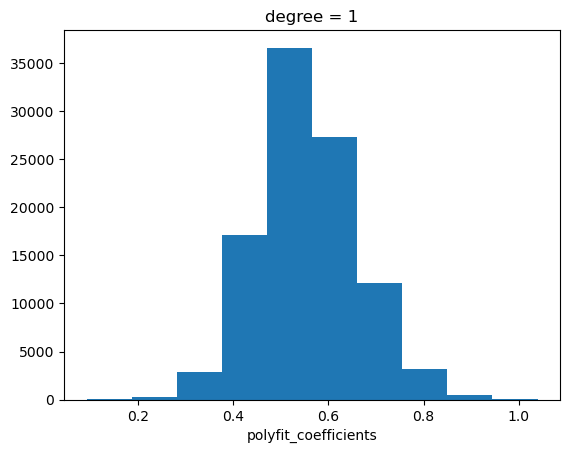

[0.398958   0.54754674 0.73782257]
<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(0.56)
Coordinates:
    degree   int64 8B 1 0.10401695441496547


In [9]:
dFdt = 10*erf_total.sel(time=ceres_tsel).polyfit(deg=1,dim='time').polyfit_coefficients[0]

dFdt.plot.hist()
plt.show()

print(dFdt.quantile([0.05,0.50, 0.95]).values)
print(dFdt.mean().round(2), dFdt.std().values)

## N (EEI): TOA imbalance

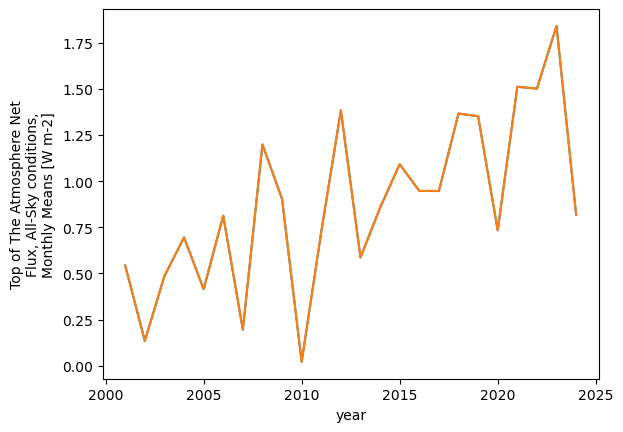

In [16]:
path = 'ceres_ebaf/ceres_ebaf/dl_20260602_globalmeanTOA/'
fname = 'CERES_EBAF_Ed4.2.1_Subset_200003-202512.nc'
ceres = xr.open_dataset(global_dpath + path + fname).sel(
    time=slice('2001-01-01','2024-12-31')).groupby('time.year').mean()
ceres['gtoa_net_all_mon'].plot()

plt.show()